# OPTICS (Ordering Points To Identify the Clustering Structure)

## ¿Qué es?

OPTICS es una variante de **DBSCAN** que no requiere elegir `eps` exacto. Produce un **reachability plot** (gráfico de alcance) que permite visualizar la estructura de clusters a múltiples escalas.

Conceptos clave:
- **min_samples**: igual que en DBSCAN
- **max_eps**: radio máximo de búsqueda (opcional, si es muy grande considera todos los vecinos)
- **cluster_hierarchy**: extrae clusters con diferentes umbrales ε a partir del ordenamiento OPTICS

Ventaja frente a DBSCAN: es robusto ante densidades variables entre clusters.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import OPTICS, cluster_optics_dbscan
from sklearn.preprocessing import StandardScaler

%matplotlib inline


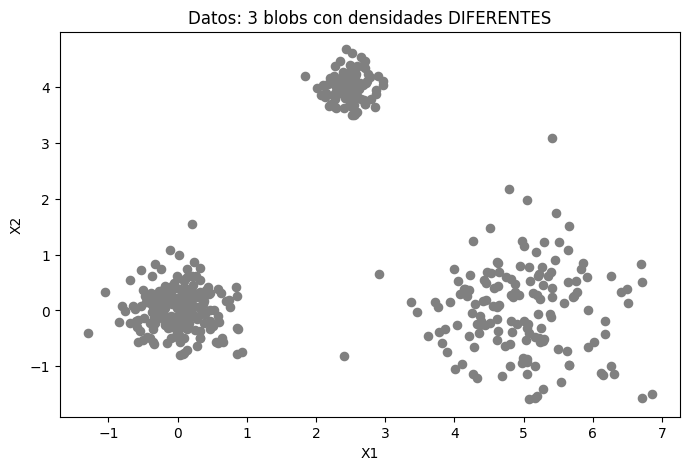

In [2]:
np.random.seed(42)

X1, _ = make_blobs(n_samples=200, centers=[[0, 0]], cluster_std=0.4, random_state=42)
X2, _ = make_blobs(n_samples=150, centers=[[5, 0]], cluster_std=0.8, random_state=42)
X3, _ = make_blobs(n_samples=100, centers=[[2.5, 4]], cluster_std=0.25, random_state=42)

X = np.vstack([X1, X2, X3])

plt.figure(figsize=(8, 5))
plt.scatter(X[:, 0], X[:, 1], c='gray', s=35)
plt.title('Datos: 3 blobs con densidades DIFERENTES')
plt.xlabel('X1'); plt.ylabel('X2')
plt.show()


## Paso 1: Aplicar OPTICS


In [3]:
X_scaled = StandardScaler().fit_transform(X)

optics = OPTICS(min_samples=10, max_eps=np.inf, xi=0.05, min_cluster_size=0.05)
optics.fit(X_scaled)

print('Etiquetas (automáticas con método xi):', np.unique(optics.labels_))
print('Número de clusters:', len(set(optics.labels_)) - (1 if -1 in optics.labels_ else 0))


Etiquetas (automáticas con método xi): [-1  0  1  2]
Número de clusters: 3


## Paso 2: Reachability Plot

Cada "valle" en el gráfico representa un cluster. La profundidad indica la separación entre clusters.


d:\py313\Lib\site-packages\matplotlib\transforms.py:2436: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),


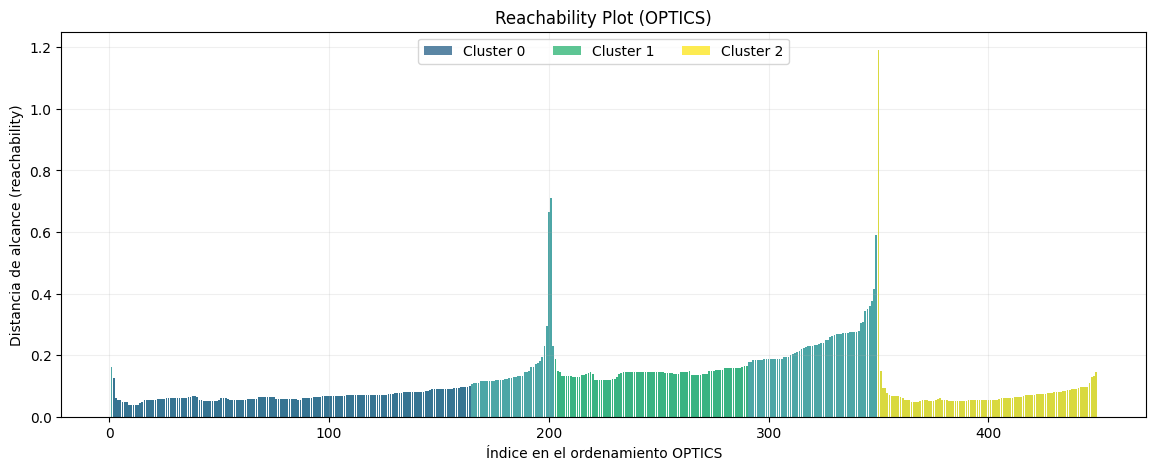

In [4]:
space = np.arange(len(X_scaled))
reachability = optics.reachability_[optics.ordering_]
labels_ordered = optics.labels_[optics.ordering_]

plt.figure(figsize=(14, 5))
plt.bar(space, reachability, color='teal', alpha=0.7)
unique_labels = np.unique(labels_ordered)
colors = plt.cm.viridis(np.linspace(0, 1, len(unique_labels)))
for k, col in zip(unique_labels, colors):
    if k == -1:
        continue
    mask = labels_ordered == k
    plt.bar(space[mask], reachability[mask], color=col, alpha=0.8,
            label=f'Cluster {k}')
plt.title('Reachability Plot (OPTICS)')
plt.xlabel('Índice en el ordenamiento OPTICS')
plt.ylabel('Distancia de alcance (reachability)')
plt.legend(ncol=4)
plt.grid(True, alpha=0.2)
plt.show()


## Paso 3: Extraer clusters a diferentes escalas (ε)

Podemos usar `cluster_optics_dbscan` para extraer clusters con distintos `eps` **sin reajustar el modelo**.


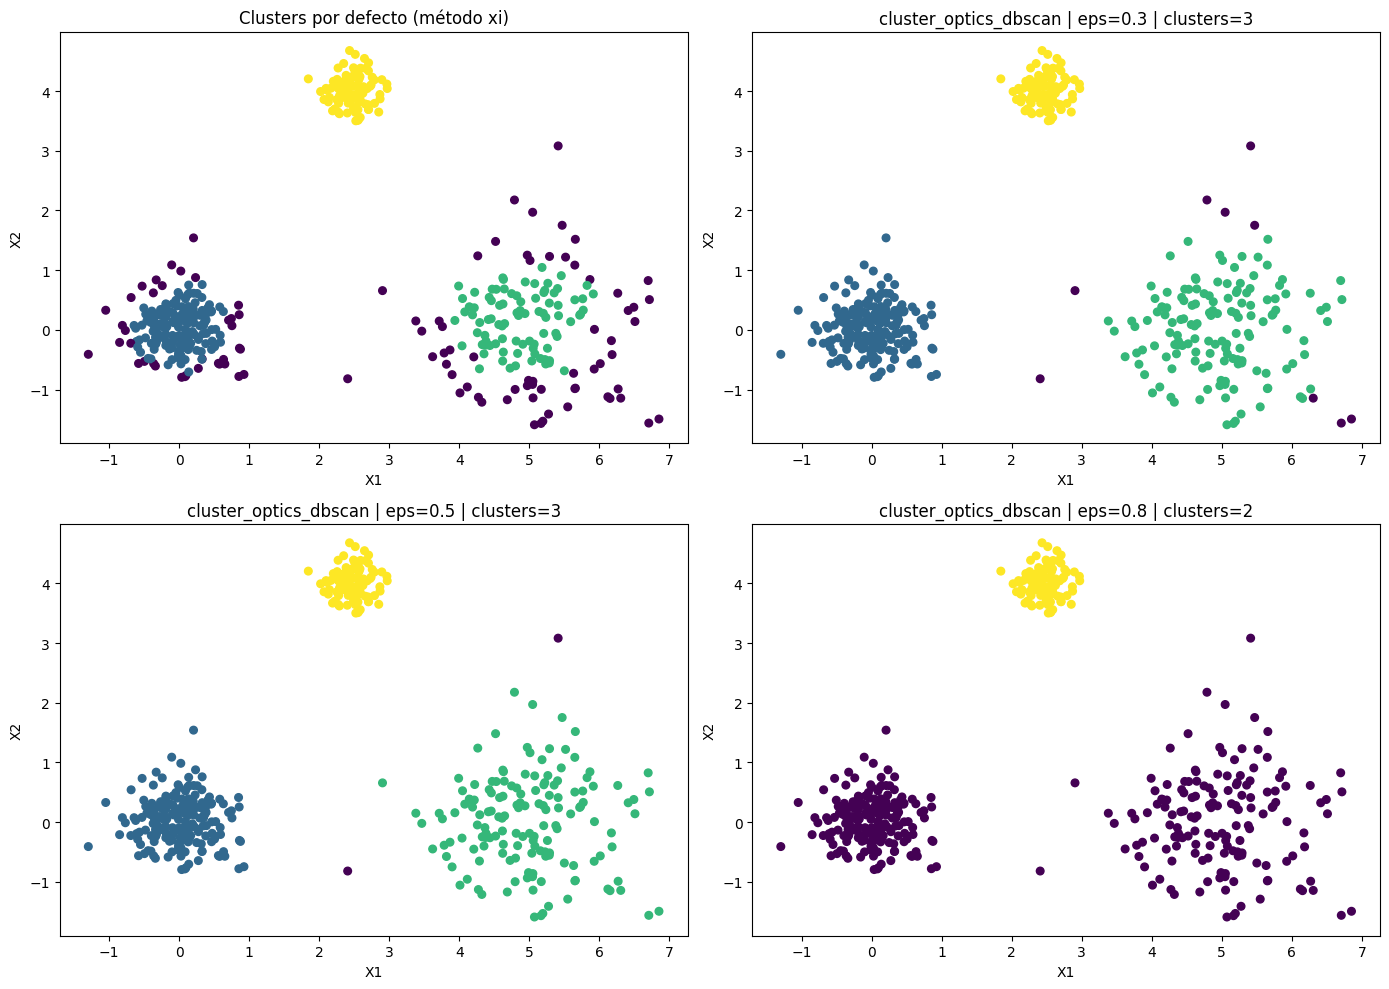

In [5]:
eps_values = [0.3, 0.5, 0.8]
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

axes[0].scatter(X[:, 0], X[:, 1], c=optics.labels_, cmap='viridis', s=30)
axes[0].set_title('Clusters por defecto (método xi)')

for i, eps in enumerate(eps_values, start=1):
    lbls = cluster_optics_dbscan(reachability=optics.reachability_,
                                 core_distances=optics.core_distances_,
                                 ordering=optics.ordering_, eps=eps)
    n_clusters = len(set(lbls)) - (1 if -1 in lbls else 0)
    axes[i].scatter(X[:, 0], X[:, 1], c=lbls, cmap='viridis', s=30)
    axes[i].set_title(f'cluster_optics_dbscan | eps={eps} | clusters={n_clusters}')

for ax in axes:
    ax.set_xlabel('X1'); ax.set_ylabel('X2')
plt.tight_layout()
plt.show()


## Resumen OPTICS vs DBSCAN

| Característica | DBSCAN | OPTICS |
|---|---|---|
| Precisa eps exacto | ✔️ | ❌ |
| Maneja densidades variables | Pobre | Bueno |
| Visualización de jerarquía | ❌ | ✔️ (reachability plot) |
| Velocidad | Más rápido | Más lento (más memoria) |
| Extracción múltiple de clusters | Requiere reentrenar | Una sola pasada |
